Hooks
--

<img src='https://www.janestreet.com/puzzles/hooks_grid.png' width=500 align='center'/>

In the grid below, enter nine 9’s in the outermost hook, eight 8’s in the next hook, then seven 7’s, six 6’s, and so on, down to the one 1 (already entered), so that the row and column sums match the values given along the border.

Once you’ve completed the puzzle, submit as your answer the sum of the values of the shaded squares.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ortools.sat.python import cp_model

Visualisation
--

Create a little function that plots the grid and outputs the sum of the shaded squares.

In [79]:
def grid_plotter(array: np.array, x_list: np.array, y_list: np.array) -> None:
    mask = [[(i + j) % 2 == 0 for i in range(9)] for j in range(9)]
    mask = np.array(mask)
    ax = sns.heatmap(
        array, cmap="tab10", annot=True, annot_kws={"fontsize":20, "color": "black"}, cbar=False, linewidths=2, linecolor="black",
        xticklabels=x_list, yticklabels=y_list
    )
    ax.tick_params(axis="both", length=0, rotation=0, labelsize=16)
    ax.xaxis.tick_top()
    plt.figure(figsize = (8,8))
    plt.show()
    print(f"SOLUTION: {sum(array[mask])}")

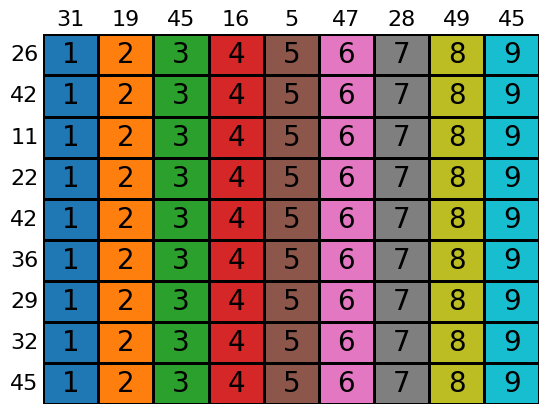

<Figure size 800x800 with 0 Axes>

SOLUTION: 205


In [80]:
#Testing the function
x_list = [31, 19, 45, 16, 5, 47, 28, 49, 45]
y_list = [26, 42, 11, 22, 42, 36, 29, 32, 45]

grid = [[x for x in range(1,10)] for _ in range(9)]
grid = np.array(grid)

grid_plotter(grid,x_list, y_list)

Solution to puzzle
--

Encode constraints for ORTools constraint solver. 

We use a normal grid containing int variables for the values and a boolean grid containing whether or not the values will be used.

Ran it without specifying the number of numbers within each hook and still achieved the correct solution, likely unique.

Found solution
Time elapsed is 0.02 seconds


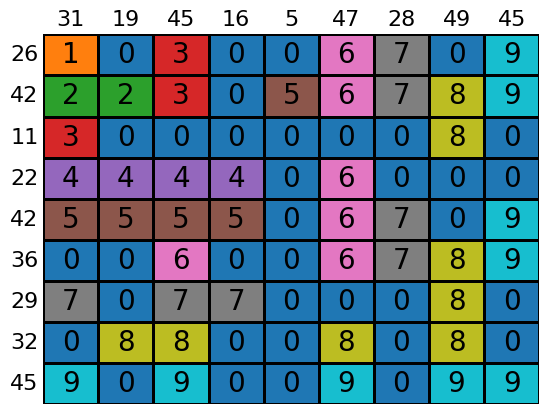

<Figure size 800x800 with 0 Axes>

SOLUTION: 158


In [82]:
start = time.perf_counter()
model = cp_model.CpModel()

n = 9
#int variable grid
X = np.array([[model.NewIntVar(0, 9, f"x{[j, i]}") for i in range(1,n+1)] for j in range(1,n+1)])

#boolean grid to determine whether this square will be used or not
B = np.array([[model.NewBoolVar(f"b{[j, i]}") for i in range(1,n+1)] for j in range(1,n+1)])

#place the 1 in the first square
model.add(X[0,0] == 1)

#sum row & column constraints
for idx, row in enumerate(X):
    e = cp_model.LinearExpr.Sum(row)
    model.add(e == y_list[idx])

for idx, row in enumerate(X.T):
    e = cp_model.LinearExpr.Sum(row)
    model.add(e == x_list[idx])

#constraints for only the same numbers within each hook. Print temp = [[j + 1 for i in range(j + 1)] for j in range(n)] to see the magic
_ = [[model.Add(X[j, i] == j+1).OnlyEnforceIf(B[j,i]) for i in range(j + 1)] for j in range(n)]
_ = [[model.Add(X[j, i] == 0).OnlyEnforceIf(B[j,i].Not()) for i in range(j + 1)] for j in range(n)]

_ = [[model.Add(X.T[j, i] == j+1).OnlyEnforceIf(B.T[j,i]) for i in range(j + 1)] for j in range(n)]
_ = [[model.Add(X.T[j, i] == 0).OnlyEnforceIf(B.T[j,i].Not()) for i in range(j + 1)] for j in range(n)]

s = cp_model.CpSolver()

status = s.solve(model)

if cp_model.FEASIBLE:
    sol = np.array([[s.value(X[j, i]) for i in range(n)] for j in range(n)])
    print("Found solution")
    end = time.perf_counter()
    print(f"Time elapsed is {(end - start):.2f} seconds")
    grid_plotter(sol, x_list, y_list)